# Diabetes Prediction - Machine Learning Workflow
Reference style similar to Loan Approval notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

df=pd.read_csv('/Users/jhansisiva/Documents/Win college /sem5/Machine Learning/lab_Assignments/Assignment1/diabetes_prediction_dataset.csv')
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 1. Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS

Target Column Detected : diabetes

Dataset Shape:
(100000, 9)

Column Names:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      

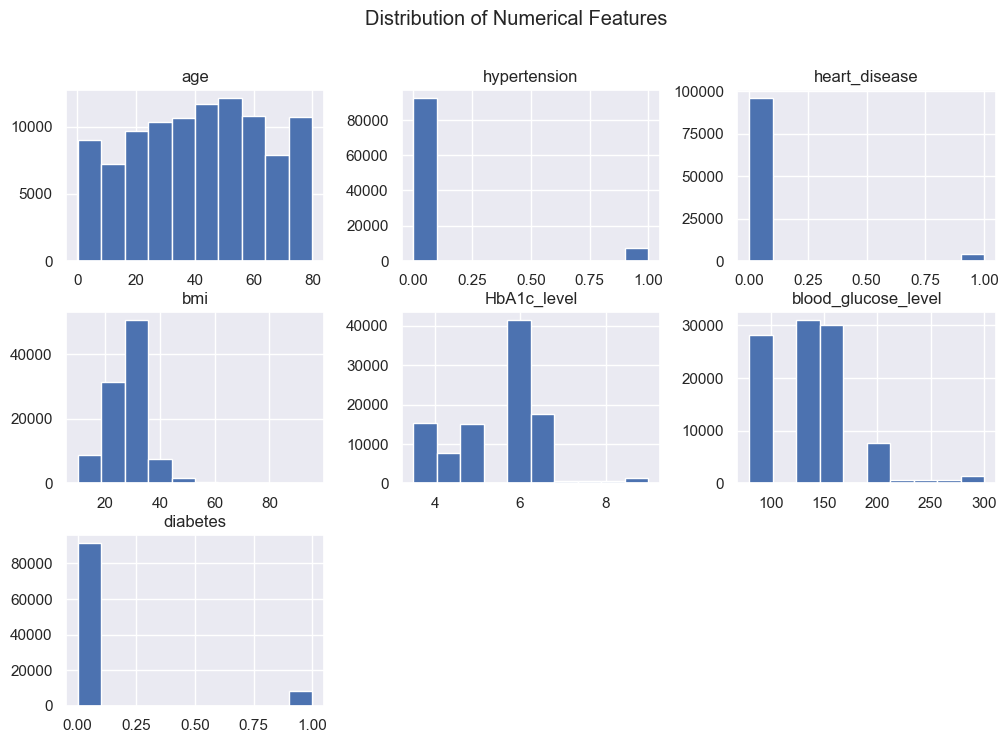


Outlier Detection


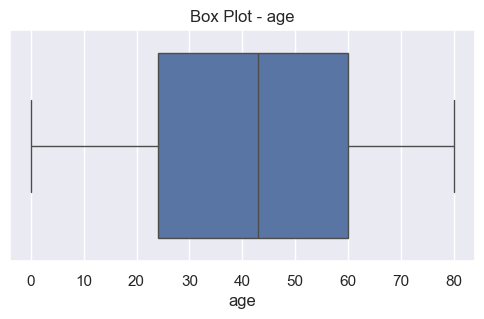

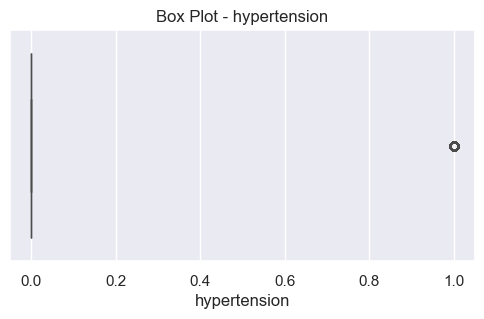

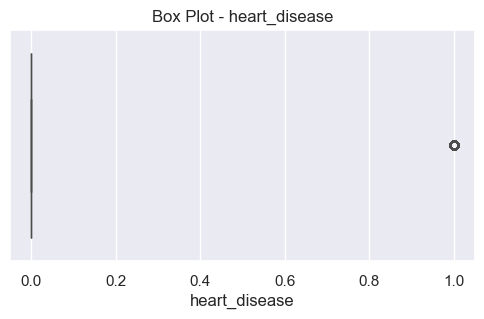

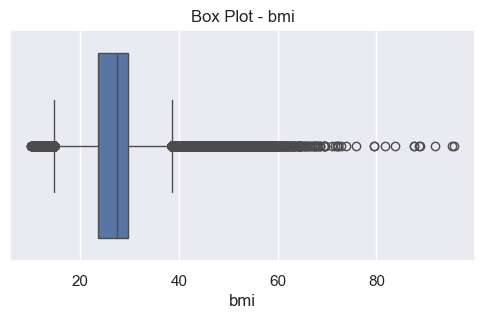

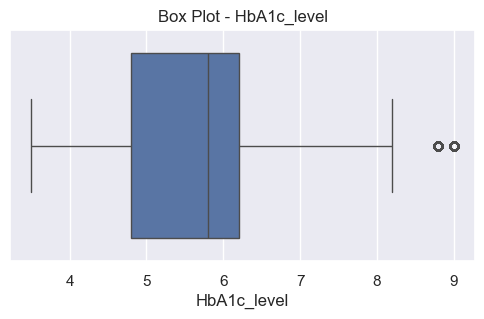

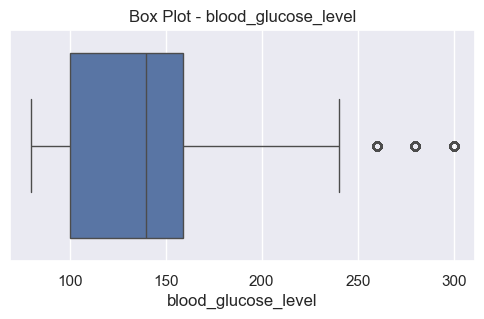

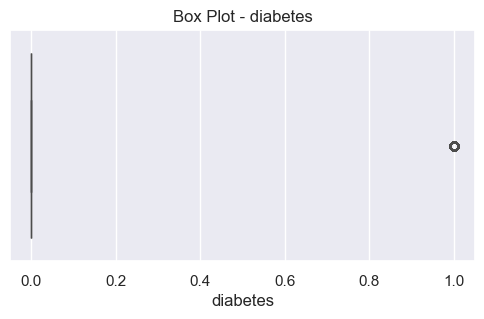


Correlation Heatmap


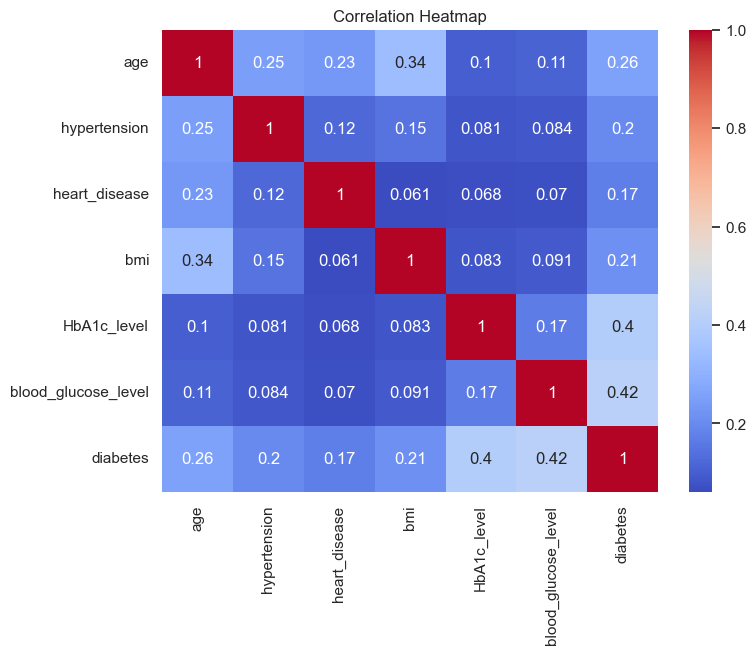


Pair Plot


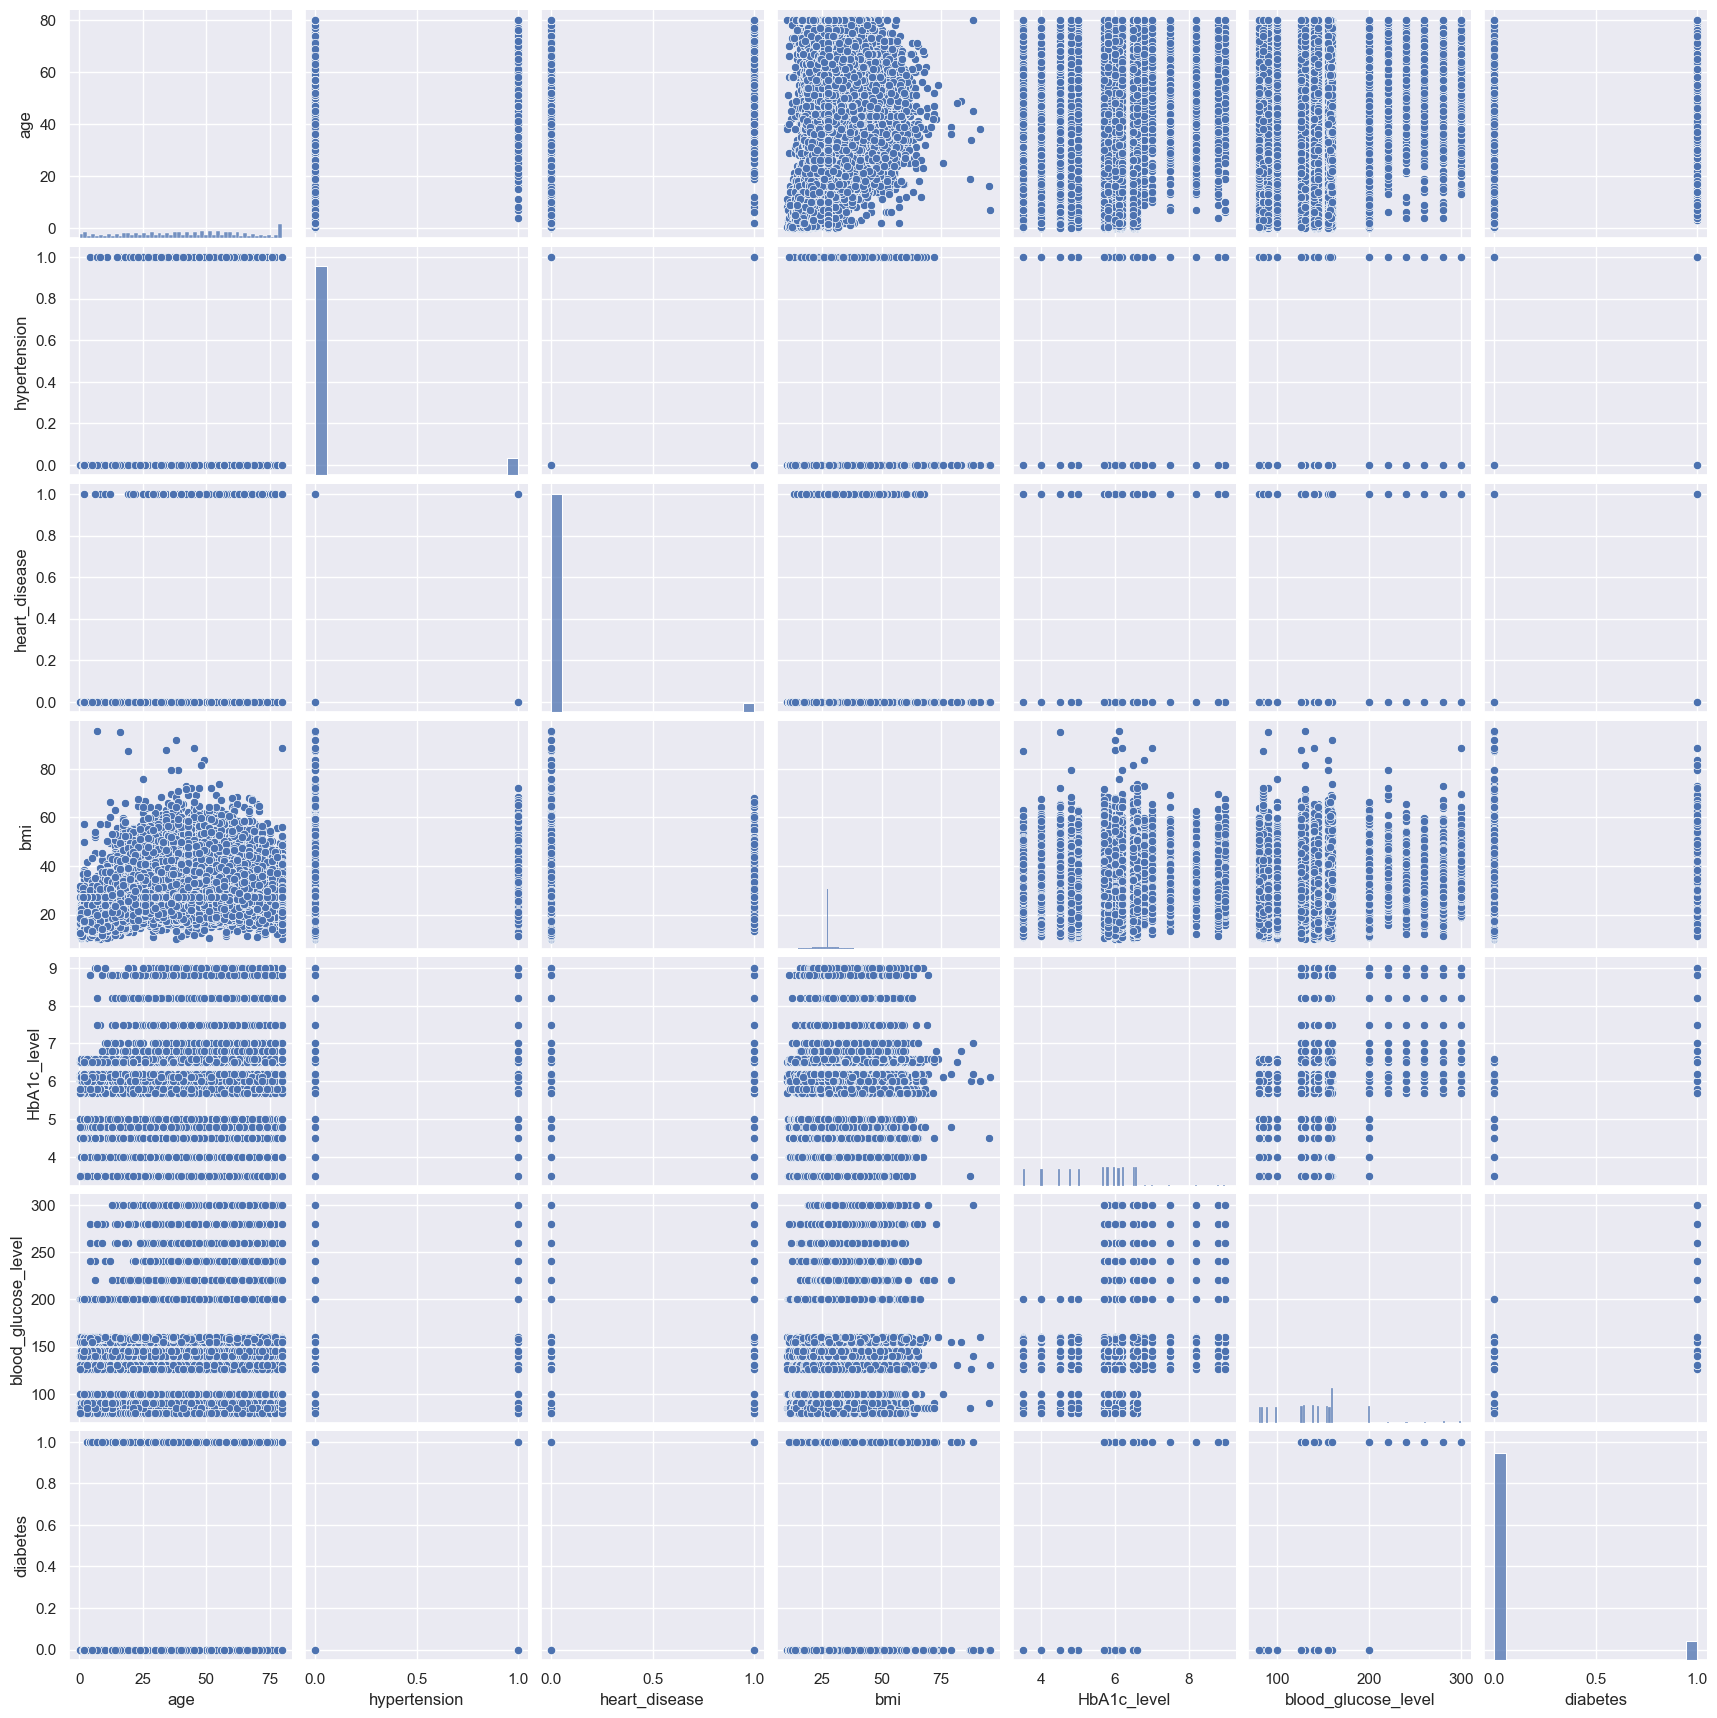


Categorical Feature Analysis


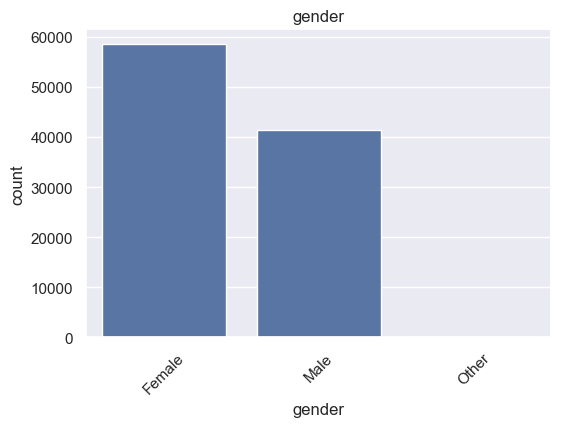

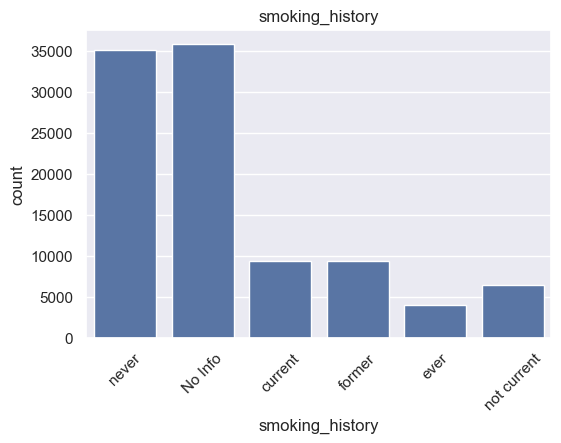


EDA Completed Successfully


In [2]:
def perform_eda(df):
    sns.set()

    print("=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Automatically detect target column
    target = df.columns[-1]

    print("\nTarget Column Detected :", target)

    
    # Dataset Information
    

    print("\nDataset Shape:")
    print(df.shape)

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nDataset Information:")
    df.info()

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nLast 5 Rows")
    print(df.tail())

   
    # Missing Values
    
    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nMissing Value Percentage")
    print((df.isnull().sum() / len(df)) * 100)

    # Duplicate Values
   
    print("\nDuplicate Rows :", df.duplicated().sum())

    # Statistical Summary
   
    print("\nStatistical Summary")
    print(df.describe(include="all"))

    
    # Numeric & Categorical Columns
    

    numeric = df.select_dtypes(include="number").columns    #specifies the columns which are having an int as an data type
    categorical = df.select_dtypes(include=["object", "category"]).columns    #specifies the object and the numerical data type colmns 

    print(f"\nThe numerical columns are {numeric}\n")
    print(f"\nThe categorical columns are {categorical}\n")

   
    # Distribution Analysis
   

    if len(numeric) > 0:

        print("\nDistribution Analysis")

        df[numeric].hist(figsize=(12, 8))

        plt.suptitle("Distribution of Numerical Features")

        plt.show()

   
    # Outlier Detection
    

    if len(numeric) > 0:

        print("\nOutlier Detection")

        for col in numeric:

            plt.figure(figsize=(6, 3))

            sns.boxplot(x=df[col])

            plt.title(f"Box Plot - {col}")

            plt.show()

   
    # Correlation Heatmap
    

    if len(numeric) > 1:

        print("\nCorrelation Heatmap")

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            df[numeric].corr(),
            annot=True,
            cmap="coolwarm"
        )

        plt.title("Correlation Heatmap")

        plt.show()

   
    # Pair Plot
    

    if len(numeric) > 1:

        print("\nPair Plot")

        pair_columns = list(numeric)

        if target not in pair_columns:
            pair_columns.append(target)

        if target in categorical:

            sns.pairplot(df[pair_columns], hue=target)

        else:

            sns.pairplot(df[pair_columns])

        plt.show()

   
    # Relationship Between Target & Features
    

    if target in categorical:

        print("\nRelationship Between Target and Features")

        for col in numeric:

            plt.figure(figsize=(6, 4))

            sns.boxplot(
                x=df[target],
                y=df[col]
            )

            plt.title(f"{col} vs {target}")

            plt.show()

    
    # Categorical Feature Analysis
    
    if len(categorical) > 0:

        print("\nCategorical Feature Analysis")

        for col in categorical:

            plt.figure(figsize=(6, 4))

            sns.countplot(x=df[col])

            plt.xticks(rotation=45)

            plt.title(col)

            plt.show()

    print("\n" + "=" * 60)
    print("EDA Completed Successfully")
    print("=" * 60)



perform_eda(df)


## 2. Data Preprocessing

In [ ]:
def preprocess_data(df):
    data=df.copy()

    # Missing Values
    num_cols=data.select_dtypes(include=['int64','float64']).columns
    cat_cols=data.select_dtypes(include='object').columns

    data[num_cols]=SimpleImputer(strategy='median').fit_transform(data[num_cols])
    data[cat_cols]=SimpleImputer(strategy='most_frequent').fit_transform(data[cat_cols])

    # Encode Categorical Variables
    encoder=LabelEncoder()
    for col in cat_cols:
        data[col]=encoder.fit_transform(data[col])

    # Features and Target
    X=data.drop('diabetes',axis=1)
    y=data['diabetes']

    # Standardization
    scaler=StandardScaler()
    X_scaled=pd.DataFrame(scaler.fit_transform(X),columns=X.columns)

    return X,X_scaled,y

X_original,X_scaled,y=preprocess_data(df)
X_scaled.head()


## 3. Feature Selection

In [ ]:
def feature_selection(X_original,X_scaled,y):

    # ANOVA
    anova=SelectKBest(score_func=f_classif,k='all')
    anova.fit(X_scaled,y)

    # Chi Square requires non-negative values
    X_positive=X_original.copy()
    for col in X_positive.columns:
        min_val=X_positive[col].min()
        if min_val<0:
            X_positive[col]=X_positive[col]-min_val

    chi=SelectKBest(score_func=chi2,k='all')
    chi.fit(X_positive,y)

    scores=pd.DataFrame({
        'Feature':X_original.columns,
        'ANOVA Score':anova.scores_,
        'Chi2 Score':chi.scores_
    })

    return scores.sort_values(by='ANOVA Score',ascending=False)

feature_scores=feature_selection(X_original,X_scaled,y)
display(feature_scores)


## 4. Train Validation Test Split

In [ ]:
def split_data(X,y):
    X_train,X_temp,y_train,y_temp=train_test_split(
        X,y,test_size=0.30,random_state=42,stratify=y)

    X_val,X_test,y_val,y_test=train_test_split(
        X_temp,y_temp,test_size=0.50,random_state=42,stratify=y_temp)

    print("Training :",X_train.shape)
    print("Validation :",X_val.shape)
    print("Testing :",X_test.shape)

    return X_train,X_val,X_test,y_train,y_val,y_test

X_train,X_val,X_test,y_train,y_val,y_test=split_data(X_scaled,y)


## 5. Performance Evaluation

In [ ]:
def evaluate_model(X_train,X_test,y_train,y_test):

    model=LogisticRegression(max_iter=1000,random_state=42)
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    print("Accuracy :",accuracy_score(y_test,y_pred))
    print("\nClassification Report\n")
    print(classification_report(y_test,y_pred))

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test,y_pred),
                annot=True,
                fmt='d',
                cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate_model(X_train,X_test,y_train,y_test)
